# Init

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from qutip import *
import numpy as np
from qutip import basis, spin_Jy, spin_Jz
from io import BytesIO
from PIL import Image
from tomo_plot_hammer import *

import matplotlib.pyplot as plt
from IPython.display import display
from ipywidgets import interact, IntSlider

In [20]:
j=7/2
Ix = jmat(j,'x')
Iy = jmat(j,'y')
Iz = jmat(j,'z')


In [21]:
def initial_state(theta, phi, j):
    dim = int(2*j + 1)
    
    psi0 = basis(dim, 0)
    psi_normal = Displace(theta, phi, psi0, j)

    return psi_normal

In [22]:
def Displace(theta, phi, psi, j):
    #### This will displace a cohernet state to some theta phi ####
    spin_dim = j

    Ip = jmat(spin_dim, '+')
    Im = jmat(spin_dim, '-')
        
    D = (theta/2*(np.exp(1j*phi)*Im - np.exp(-1j*phi)*Ip)).expm()
    return D * psi

In [23]:
-Ix@Iy+Iy@Ix

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.-3.5j 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.-2.5j 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.-1.5j 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.-0.5j 0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.5j 0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.5j 0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+2.5j 0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+3.5j]]

In [24]:
def kicked_dynamics(psi_initial, tau, kappa, j, N = 1):
    # Spin is 7/2 => dimension is 8
    S = j
    dim = int(2*S + 1)
    # Parameters
    chi = np.pi/2

    # QuTiP spin operators
    Jx = spin_Jx(S)
    Jy = spin_Jy(S)
    Jz = spin_Jz(S)

    # Free Hamiltonian H0
    H0 = (np.pi/(2)) * -Jy
    # Precompute the free evolution operator for time tau
    U0 = (-1j * H0 * tau).expm()
    # Larmor pulse unitary (instantaneous)
    Ularmor = (-1j * chi * (Jz)).expm()
    # Precompute the pulse unitary (instantaneous)
    Upulse = (-1j * (kappa/(2.0 * S)) * (Jz**2)).expm()

    # Evolve the state stroboscopically
    psi = psi_initial          # Start with the prepared state
    psi_list = [psi]           # Store states after each pulse
    overlap_list = [psi.overlap(psi_initial)]  # Overlap with the initial state
    entropy_list  = [qudit_linear_entropy(psi, j)]
    exp_list = [qudit_exp(psi, j)]

    for n in range(N):
        # 1) Free evolution for time tau
        # psi = U0 * psi

        # 2) Instantaneous pulse
        # psi = Upulse * psi
        psi = Ularmor * psi

        # Store the new state and its overlap with the initial state
        psi_list.append(psi)
        overlap_list.append(psi.overlap(psi_initial))
        entropy_list.append(qudit_linear_entropy(psi, j))
        exp_list.append(qudit_exp(psi, j))

    return psi_list, overlap_list, entropy_list

In [25]:
def qudit_exp(psi, j):
    Ix = jmat(j,'x')
    Iy = jmat(j,'y')
    Iz = jmat(j,'z')
    exp_x = expect(Ix, psi)
    exp_y = expect(Iy, psi)
    exp_z = expect(Iz, psi)
    exp_array = [exp_x, exp_y, exp_z]
    return exp_array

In [26]:
def qudit_linear_entropy(psi, j):
    Ix = jmat(j,'x')
    Iy = jmat(j,'y')
    Iz = jmat(j,'z')
    entropy = 1/2*(1 - (expect(Ix, psi)**2 + expect(Iy, psi)**2 + expect(Iz, psi)**2)/(j)**2)
    return entropy

# State evolution on Husimi

In [27]:
spin = 3.5
psi_initial = initial_state(2.25, 0.7, j=spin)
psi_initial = initial_state(0.5*np.pi,0, j=spin)

n_kicks = 16
psi_lst = kicked_dynamics(psi_initial, tau=1, kappa=3, j=spin, N = n_kicks)
#### put figures into a slider
def show_frame(kick):
    tomo_plot_hammer(psi_lst[0][kick], "h")  # This creates and shows the figure
interact(show_frame, kick=IntSlider(min=0, max=n_kicks, step=1, value=0, layout={'width': '800px'}))

interactive(children=(IntSlider(value=0, description='kick', layout=Layout(width='800px'), max=16), Output()),…

<function __main__.show_frame(kick)>

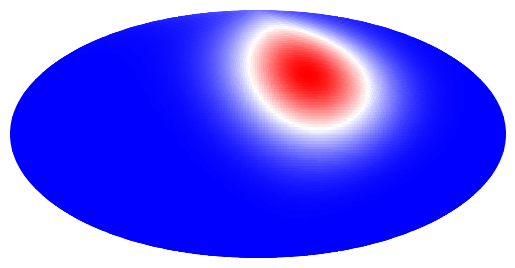

AttributeError: 'NoneType' object has no attribute 'savefig'

In [11]:
import os
import imageio
import matplotlib.pyplot as plt

# Create a folder for frames
os.makedirs("frames", exist_ok=True)

# Generate and save frames
for i in range(n_kicks + 1):
    fig = tomo_plot_hammer(psi_lst[0][i], "h")  # Get the figure object
    filename = f"frames/frame_{i:03d}.png"
    fig.savefig(filename, bbox_inches='tight')
    plt.close(fig)  # Close explicitly to avoid memory buildup

# Assemble frames into GIF
frames = []
for i in range(n_kicks + 1):
    image_path = f"frames/frame_{i:03d}.png"
    frames.append(imageio.imread(image_path))

# Save as GIF
imageio.mimsave("kicked_dynamics.gif", frames, duration=0.2)


In [ ]:
data = psi_lst[0]
overlap =  np.zeros(len(data))
# for i in range(len(data)):
for i in range(len(data)):
    overlap[i] = fidelity(data[0],data[i])
# plt.xlim(0,18)
plt.plot(np.arange(len(data)),overlap)


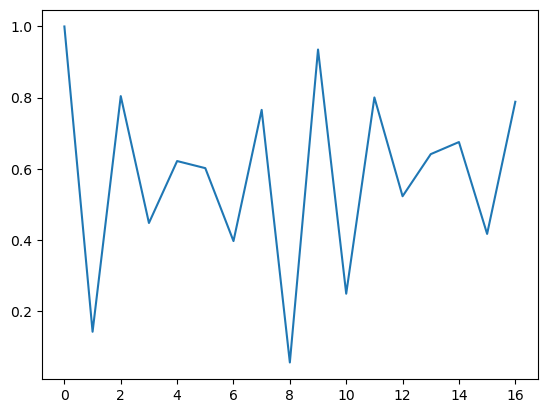

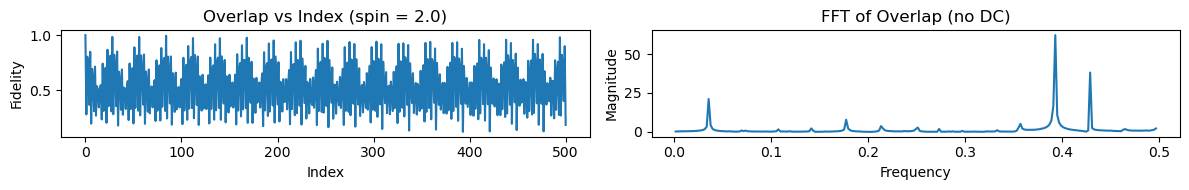

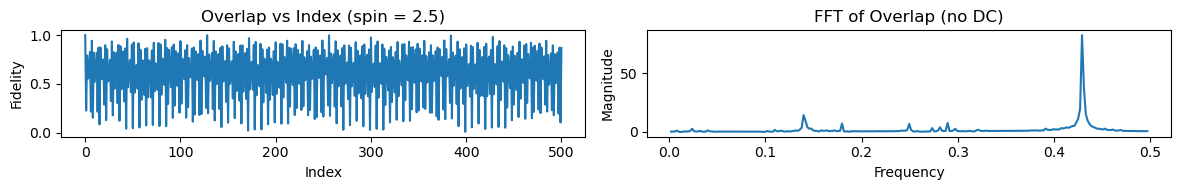

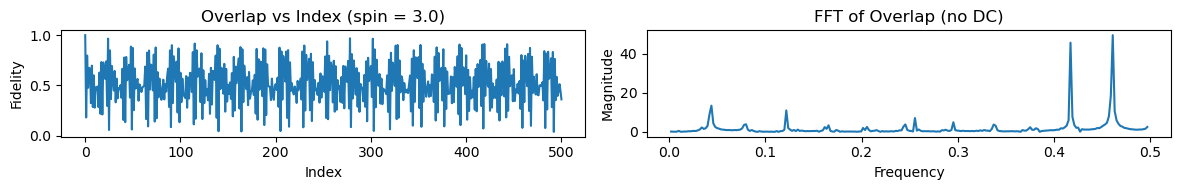

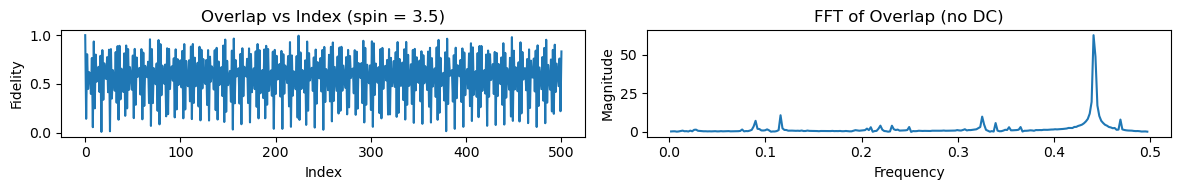

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import fidelity  # Assuming you're using qutip for fidelity
# spin = 3
def tunnel(spin):
    psi_initial = initial_state(2.25, 0.7, j=spin)
    
    n_kicks = 500
    psi_lst = kicked_dynamics(psi_initial, tau=1, kappa=3, j=spin, N = n_kicks)
    #### put figures into a slider
    
    data = psi_lst[0]
    overlap = np.zeros(len(data))
    
    for i in range(len(data)):
        overlap[i] = fidelity(data[0], data[i])
    
    # Plot 1: Overlap over time
    plt.figure(figsize=(12,2))
    
    plt.subplot(1, 2, 1)
    plt.plot(np.arange(len(data)), overlap)
    plt.title(f"Overlap vs Index (spin = {spin})")
    plt.xlabel("Index")
    plt.ylabel("Fidelity")
    
    # Compute FFT
    fft_vals = np.fft.fft(overlap)
    fft_freqs = np.fft.fftfreq(len(overlap))
    
    # Remove DC component (index 0)
    fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
    fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]
    
    # Plot 2: FFT Magnitude without DC
    plt.subplot(1, 2, 2)
    plt.plot(fft_freqs_no_dc, np.abs(fft_vals_no_dc))
    plt.title("FFT of Overlap (no DC)")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    
    plt.tight_layout()
    plt.show()
for i in np.arange(2,4, 0.5):
    tunnel(i)

/var/folders/t_/r65y_13j39526wrmgrvth29h0000gn/T/ipykernel_12157/2347200110.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


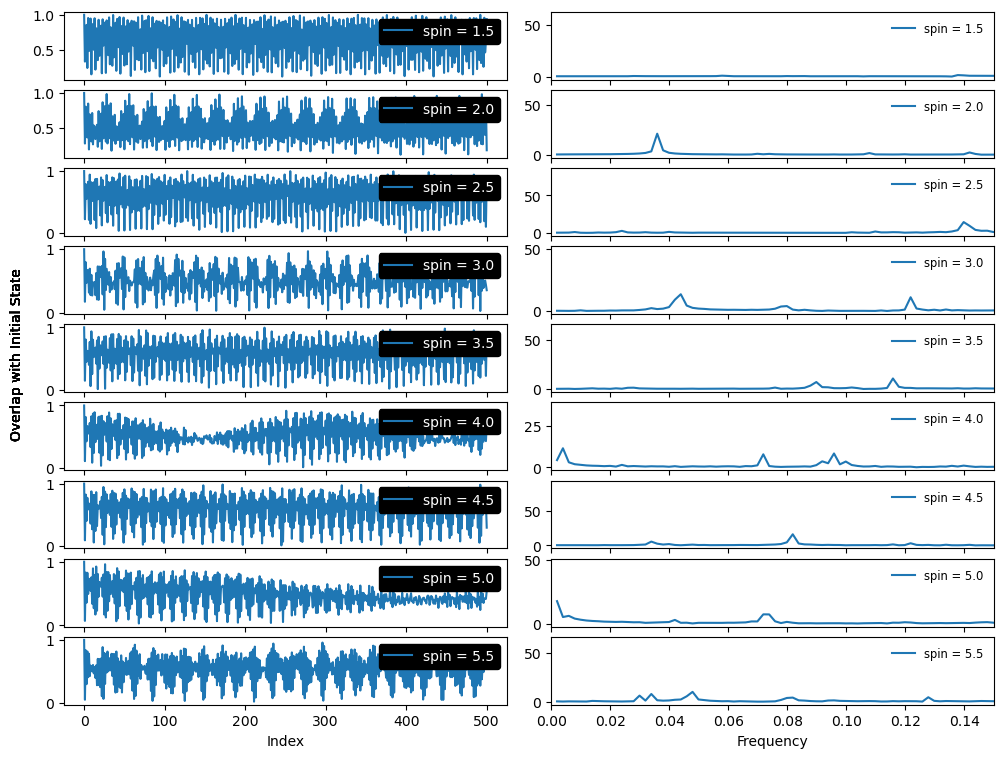

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import fidelity  # Assuming you're using qutip for fidelity

def tunnel(spin):
    psi_initial = initial_state(2.25, 0.7, j=spin)
    
    n_kicks = 500
    psi_lst = kicked_dynamics(psi_initial, tau=1, kappa=3, j=spin, N=n_kicks)
    data = psi_lst[0]
    
    overlap = np.zeros(len(data))
    for i in range(len(data)):
        overlap[i] = fidelity(data[0], data[i])

    fft_vals = np.fft.fft(overlap)
    fft_freqs = np.fft.fftfreq(len(overlap))
    fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
    fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]

    return overlap, fft_freqs_no_dc, np.abs(fft_vals_no_dc)

# Spin values
spin_values = np.arange(1.5, 6, 0.5)
n_rows = len(spin_values)

# Create figure
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(12, 1 * n_rows), sharex='col', gridspec_kw={'hspace': 0.15})
plt.subplots_adjust(hspace=0.05, wspace=0.1)

for i, spin in enumerate(spin_values):
    overlap, freqs, fft_mag = tunnel(spin)

    # Left column: overlap
    ax1 = axes[i, 0]
    ax1.plot(np.arange(len(overlap)), overlap, label=f"spin = {spin}")
    # ax1.legend(loc="upper right", fontsize="small", frameon=False)
    ax1.legend(
    loc="upper right",
    fontsize=10,
    facecolor="black",
    edgecolor="black",
    framealpha=1.0,       # fully opaque
    labelcolor="white"    # this works in Matplotlib ≥ 3.5
)
    # ax1.set_ylabel("Fidelity")
    fig.text(0.08, 0.5, 'Overlap with Initial State', va='center', rotation='vertical', fontsize=10,fontweight='light')
    if i == n_rows - 1:
        ax1.set_xlabel("Index")
    else:
        ax1.tick_params(labelbottom=False)  # hide x-ticks except for bottom row

    # Right column: FFT
    ax2 = axes[i, 1]
    ax2.plot(freqs, fft_mag, label=f"spin = {spin}")
    ax2.set_xlim(0, 0.15)
    ax2.legend(loc="upper right", fontsize="small", frameon=False)

    if i == n_rows - 1:
        ax2.set_xlabel("Frequency")
    else:
        ax2.tick_params(labelbottom=False)

plt.tight_layout()
plt.show()


In [ ]:
data = psi_lst[0]
overlap =  np.zeros(len(data))
# for i in range(len(data)):
for i in range(len(data)):
    overlap[i] = fidelity(data[0],data[i])
# plt.xlim(0,18)
plt.plot(np.arange(len(data)),overlap)


In [ ]:
#### print all figures
# for kick in range(n_kicks):
#     print(kick)
#     tomo_plot_hammer(psi_lst[0][kick] , "h")

In [ ]:
Uz = (-1j*Iz*np.pi).expm()
Uz

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-4.2862638e-16+1.j  0.0000000e+00-0.j  0.0000000e+00+0.j
   0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j
   0.0000000e+00+0.j  0.0000000e+00+0.j]
 [ 0.0000000e+00+0.j  3.0616170e-16-1.j  0.0000000e+00+0.j
   0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j
   0.0000000e+00+0.j  0.0000000e+00+0.j]
 [ 0.0000000e+00+0.j  0.0000000e+00+0.j -1.8369702e-16+1.j
   0.0000000e+00-0.j  0.0000000e+00+0.j  0.0000000e+00+0.j
   0.0000000e+00+0.j  0.0000000e+00+0.j]
 [ 0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j
   6.1232340e-17-1.j  0.0000000e+00+0.j  0.0000000e+00+0.j
   0.0000000e+00+0.j  0.0000000e+00+0.j]
 [ 0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j
   0.0000000e+00+0.j  6.1232340e-17+1.j -0.0000000e+00+0.j
   0.0000000e+00+0.j  0.0000000e+00+0.j]
 [ 0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j
   0.0000000e+00+0.j  0.0000000e+00+0.j -1.83697

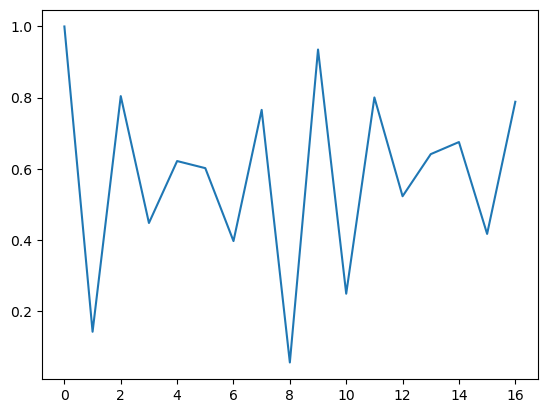

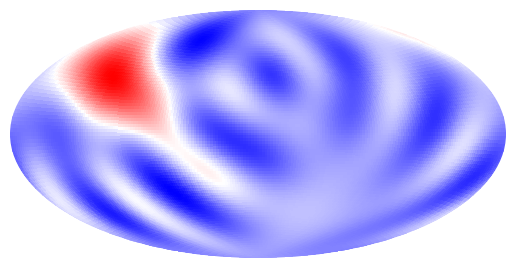

In [ ]:
tomo_plot_hammer(Uz*Qobj(psi_lst[0][2]),'w')

In [ ]:
from tomo_plot_hammer import *

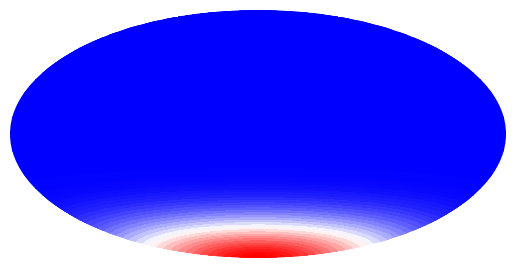

In [ ]:
psi = basis(8,0)
tomo_plot_hammer(psi, "w")

# Phase maps

In [ ]:
def analyze_entropy_distribution(num_theta, num_phi, tau, kappa, j, N):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata

    # Step 1: Generate initial states with all (theta, phi) combinations
    initial_states_with_coords = []
    thetas = np.linspace(0, np.pi, num_theta) # decide the range to simulate
    phis = np.linspace(0, np.pi, num_phi)     # decide the range to simulate

    for theta in thetas:
        for phi in phis:
            state = initial_state(theta, phi, j)
            initial_states_with_coords.append((theta, phi, state))

    # Step 2: Time evolve and extract final entropies
    entropies = []
    theta_vals = []
    phi_vals = []
    exp_list = []

    for theta, phi, state in initial_states_with_coords:
        state_t, _, entropy_t = kicked_dynamics(state, tau, kappa, j, N)
        final_entropy = entropy_t[-1]  # Or use np.mean(entropy_t[-20:]) if averaging preferred

        entropies.append(final_entropy)

        theta_vals.append(theta)
        phi_vals.append(phi)
        

    # Step 3: Convert to 2D grid for plotting
    theta_vals = np.array(theta_vals)
    phi_vals = np.array(phi_vals)
    entropies = np.array(entropies)

    grid_theta, grid_phi = np.meshgrid(thetas, phis)
    grid_entropy = griddata(
        (theta_vals, phi_vals),
        entropies,
        (grid_theta, grid_phi),
        method='cubic'
    )

    # Step 4: Plot
    plt.figure(figsize=(13,5))
    im = plt.pcolormesh(grid_phi, grid_theta, grid_entropy, shading='auto', cmap='seismic')
    # plt.xlabel("Phi (φ) [-π, 0]")
    # plt.ylabel("Theta (θ) [0, π/2]")
    plt.xticks(np.arange(0, np.pi + 0.01, 0.2*np.pi), ['0 $\pi$','0.2 $\pi$','0.4 $\pi$','0.6 $\pi$','0.8 $\pi$','1.0 $\pi$'])
    plt.yticks(np.arange(0, np.pi + 0.01, 0.2*np.pi), ['0 $\pi$','0.2 $\pi$','0.4 $\pi$','0.6 $\pi$','0.8 $\pi$','1.0 $\pi$'])
    plt.ylim(0,np.pi)
    plt.title(f'Quantum Phase Space — κ={kappa:.2f}, τ={tau:.2f}, , N={N:.2f}')
    plt.colorbar(im, label='Entropy')
    plt.show()

    # return entropies


<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid e

In [ ]:
def get_average_entropy_distribution(entropy_list, tau, kappa):

    # Step1: Calculate the average entropy
    entrop_reshaped = np.array(entropy_list).mean(axis = 0).reshape(30,30)

    # Step2: Create a 2D grid for plotting
    phi = np.linspace(0, np.pi, 30)      # x-axis
    theta = np.linspace(0, np.pi, 30)         # y-axis
    phi_grid, theta_grid = np.meshgrid(phi, theta)

    # Step 3: Plotting
    plt.figure(figsize=(8, 6))
    im = plt.pcolormesh(phi_grid, theta_grid, entrop_reshaped, shading='auto', cmap='seismic')
    # plt.xlabel("Phi (φ) [-π, 0]")
    # plt.ylabel("Theta (θ) [0, π/2]")
    plt.xticks([-np.pi, -3*np.pi/4, -np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], [r"$-\pi$", r"$-\frac{3\pi}{4}$", r"$-\frac{\pi}{2}$", r"$-\frac{\pi}{4}$", r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$"])
    plt.yticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], [r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$"])
    
    plt.title(f'Quantum Phase Space — κ={kappa:.2f}, τ={tau:.2f}')
    plt.colorbar(im, label='Entropy')
    plt.show()


In [ ]:
n_kicks=4

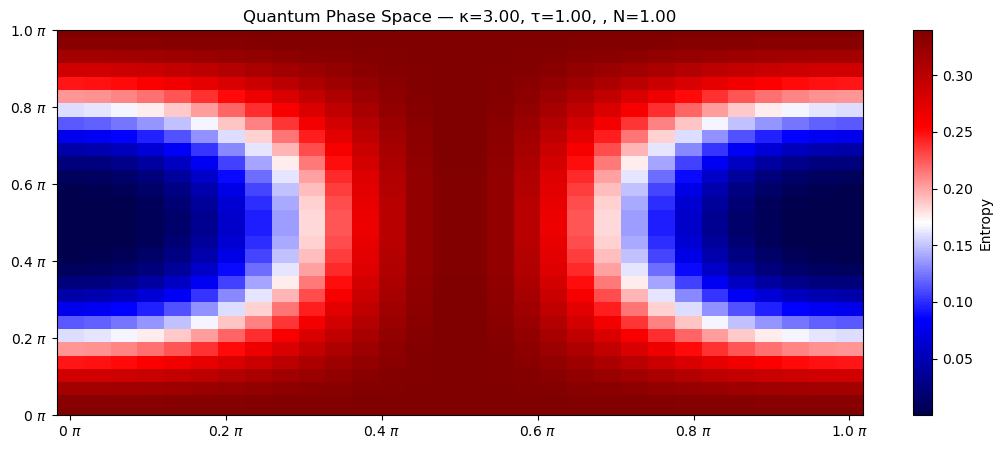

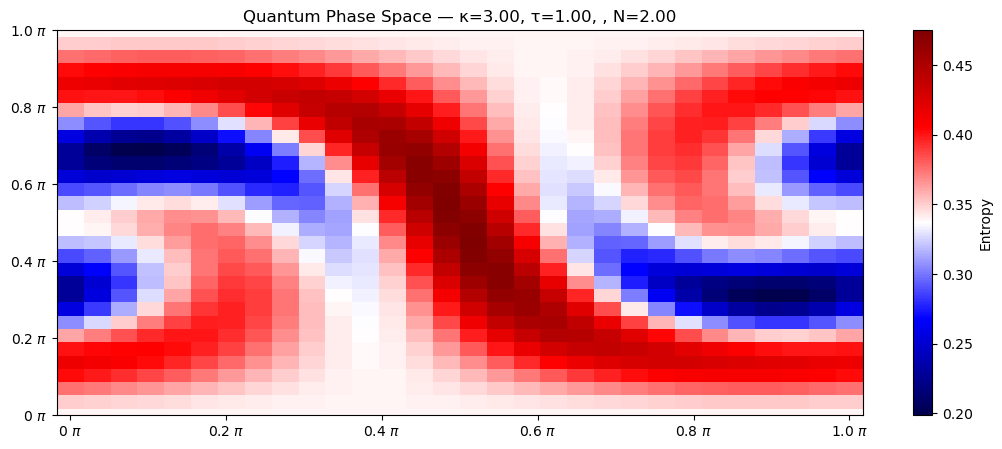

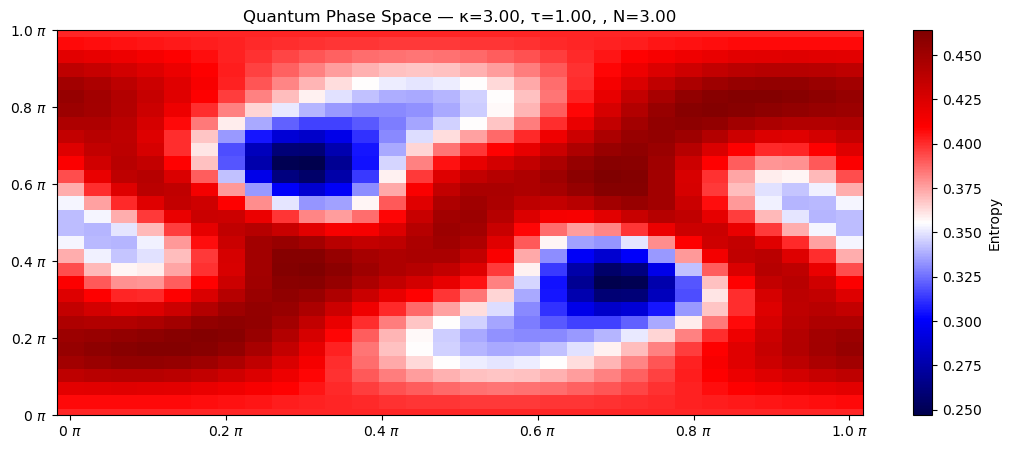

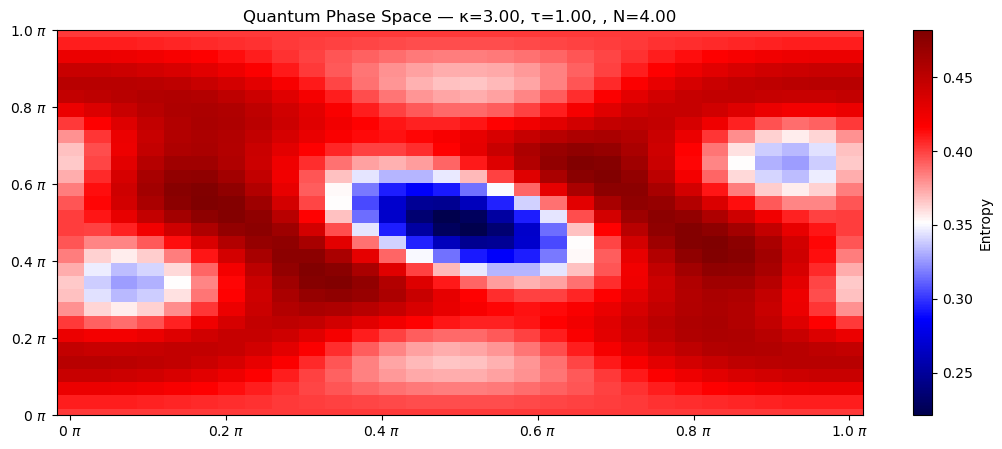

In [ ]:
for n in range(n_kicks):
    analyze_entropy_distribution(num_theta=30, num_phi=30, tau=1, kappa=3, j=7/2, N = n+1)

## Calculate the average phase map

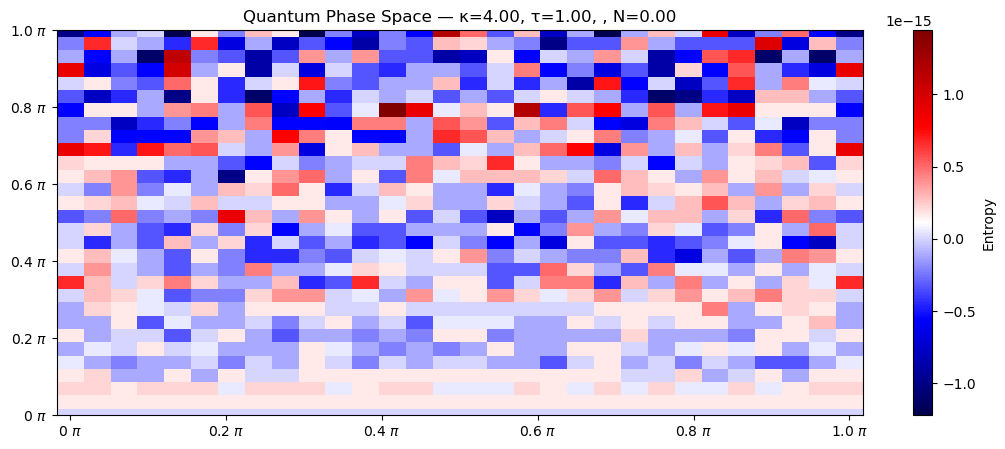

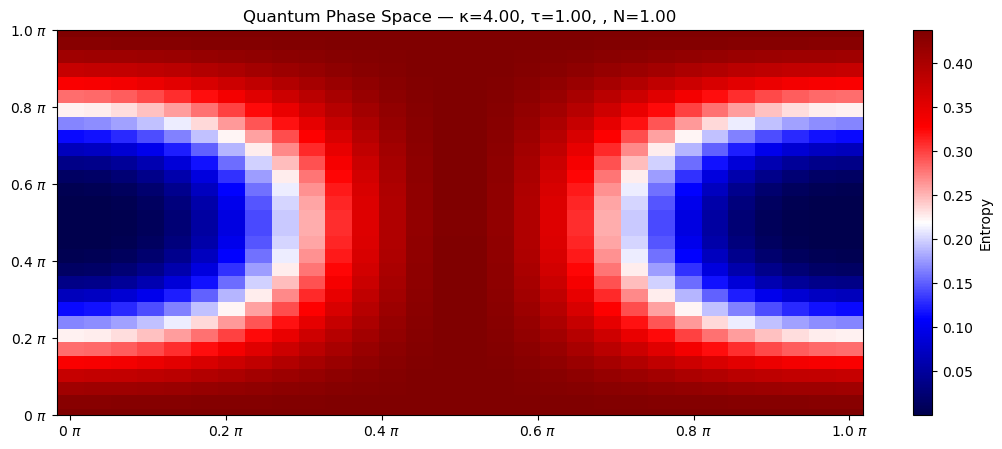

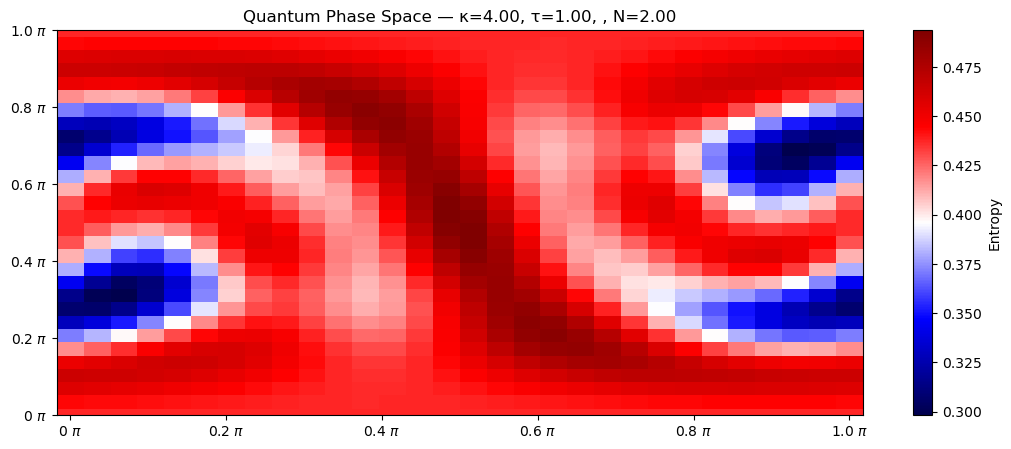

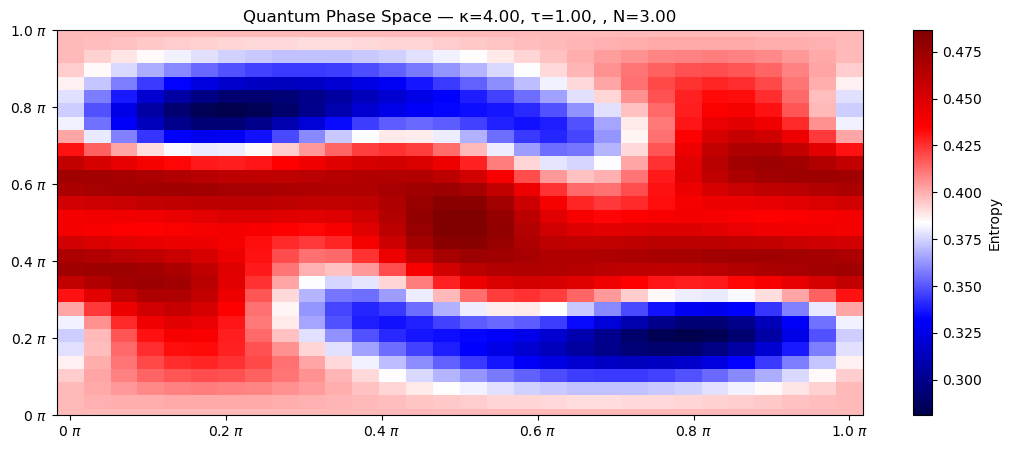

In [ ]:
entropy_list = [] #3.5*np.pi
for i in range(n_kicks):
    # print(i)
    entropy_list.append(analyze_entropy_distribution(num_theta=30, num_phi=30,  tau=1, kappa=4, j=7/2, N = i))

In [ ]:
get_average_entropy_distribution(entropy_list, tau=1, kappa=4)

TypeError: unsupported operand type(s) for +: 'NoneType' and 'NoneType'

In [ ]:
for n in range(n_kicks):
    analyze_entropy_distribution(num_theta=30, num_phi=30, tau=1, kappa=4, j=7/2, N = n)

In [ ]:
for n in range(n_kicks):
    analyze_entropy_distribution(num_theta=30, num_phi=30, tau=1, kappa=3, j=7/2, N = n)